# Train an Instance Segmentation Model using Mask R-CNN

[![image](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opengeos/geoai/blob/main/docs/examples/train_instance_segmentation_model.ipynb)

This notebook demonstrates how to train instance segmentation models for object detection (e.g., building detection) using Mask R-CNN. Unlike semantic segmentation, instance segmentation can distinguish between individual objects of the same class, providing separate masks for each instance.

## Install packages

To use the new functionality, ensure the required packages are installed.

In [1]:
%pip install geoai-py

  Using cached geoai_py-0.18.2-py2.py3-none-any.whl.metadata (11 kB)
  Using cached albumentations-2.0.8-py3-none-any.whl.metadata (43 kB)
  Using cached buildingregulariser-0.2.4-py3-none-any.whl.metadata (7.2 kB)
  Using cached contextily-1.7.0-py3-none-any.whl.metadata (3.1 kB)
  Using cached datasets-4.4.1-py3-none-any.whl.metadata (19 kB)
  Using cached ever_beta-0.5.3-py3-none-any.whl.metadata (18 kB)
  Using cached jupyter_server_proxy-4.4.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached localtileserver-0.10.7-py3-none-any.whl.metadata (5.5 kB)
  Using cached overturemaps-0.18.0-py3-none-any.whl.metadata (5.2 kB)
  Using cached planetary_computer-1.0.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached pyarrow-22.0.0-cp310-cp310-manylinux_2_28_x86_64.whl.metadata (3.2 kB)
  Using cached rioxarray-0.19.0-py3-none-any.whl.metadata (5.5 kB)
  Using cached scikit_image-0.25.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (14 kB)
  Using cached timm-1.0.22-py3

## Import libraries

In [1]:
import geoai

## Download sample data

We'll use the same dataset as the semantic segmentation example for consistency.

In [2]:
train_raster_url = (
    "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/naip_rgb_train.tif"
)
train_vector_url = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/naip_train_buildings.geojson"
test_raster_url = (
    "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/naip_test.tif"
)

In [3]:
train_raster_path = geoai.download_file(train_raster_url)
train_vector_path = geoai.download_file(train_vector_url)
test_raster_path = geoai.download_file(test_raster_url)

## Visualize sample data

In [4]:
geoai.get_raster_info(train_raster_path)

{'driver': 'GTiff',
 'width': 2503,
 'height': 1126,
 'count': 3,
 'dtype': 'uint8',
 'crs': 'EPSG:26911',
 'transform': Affine(0.6000000000000046, 0.0, 454780.8,
        0.0, -0.6, 5278242.6),
 'bounds': BoundingBox(left=454780.8, bottom=5277567.0, right=456282.6, top=5278242.6),
 'resolution': (0.6000000000000046, 0.6),
 'nodata': None,
 'band_stats': [{'band': 1,
   'min': 12.0,
   'max': 251.0,
   'mean': 150.6730747259594,
   'std': 48.01908734374099},
  {'band': 2,
   'min': 49.0,
   'max': 251.0,
   'mean': 141.92468895229808,
   'std': 43.46595463573497},
  {'band': 3,
   'min': 53.0,
   'max': 251.0,
   'mean': 120.89909373405554,
   'std': 41.78086244480775}]}

In [5]:
style_dict = {
    "color": "#ff0000",
    "weight": 2,
    "opacity": 1,
    # "fill": True,
    # "fillColor": "#ffffff",
    "fillOpacity": 0,
    # "dashArray": "9"
    # "clickable": True,
}
style_function = lambda x: style_dict

geoai.view_vector_interactive(
    train_vector_path, tiles=train_raster_path, style_function=style_function
)

In [6]:
geoai.view_raster(test_raster_path)

## Create training data

We'll create training tiles from the imagery and vector labels.

In [7]:
out_folder = "buildings_instance"
tiles = geoai.export_geotiff_tiles(
    in_raster=train_raster_path,
    out_folder=out_folder,
    in_class_data=train_vector_path,
    tile_size=512,
    stride=256,
    buffer_radius=0,
)


Raster info for naip_rgb_train.tif:
  CRS: EPSG:26911
  Dimensions: 2503 x 1126
  Resolution: (0.6000000000000046, 0.6)
  Bands: 3
  Bounds: BoundingBox(left=454780.8, bottom=5277567.0, right=456282.6, top=5278242.6)
Loaded 735 features from naip_train_buildings.geojson
Vector CRS: EPSG:4326
Reprojecting features from EPSG:4326 to EPSG:26911
Found 1 unique classes: ['building']


Generated: 36, With features: 36: 100%|██████████| 36/36 [00:03<00:00, 11.65it/s]


------- Export Summary -------
Total tiles exported: 36
Tiles with features: 36 (100.0%)
Average feature pixels per tile: 46785.7
Output saved to: buildings_instance

------- Georeference Verification -------


## Train instance segmentation model

Now we'll train an instance segmentation model using the `train_instance_segmentation_model` function. This function uses Mask R-CNN, which is specifically designed for instance segmentation tasks.

### Key Differences from Semantic Segmentation:

- **Instance Segmentation**: Identifies and segments each individual object separately (e.g., distinguishes Building A from Building B)
- **Semantic Segmentation**: Only classifies pixels into categories (all buildings are treated as one class)

### Model Architecture:

Mask R-CNN combines:
- **Faster R-CNN** for object detection (bounding boxes)
- **FCN** for pixel-level segmentation (masks)
- **ResNet-50 + FPN** backbone for feature extraction

### Training Parameters:

- `num_classes`: Number of classes including background (default: 2 for background + buildings)
- `num_channels`: Number of input channels (3 for RGB, 4 for RGBN)
- `batch_size`: Typically smaller than semantic segmentation (4-8) due to model complexity
- `num_epochs`: Number of training epochs
- `learning_rate`: Initial learning rate (default: 0.005)
- `val_split`: Fraction of data for validation (default: 0.2)

In [8]:
# Train Mask R-CNN model
geoai.train_instance_segmentation_model(
    images_dir=f"{out_folder}/images",
    labels_dir=f"{out_folder}/labels",
    output_dir=f"{out_folder}/instance_models",
    num_classes=2,  # background + building
    num_channels=3,
    batch_size=4,
    num_epochs=10,
    learning_rate=0.005,
    val_split=0.2,
    visualize=True,
    verbose=True,
)

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /home/xihan/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth
100%|██████████| 170M/170M [00:01<00:00, 115MB/s]  


Using device: cuda
Found 36 image files and 36 label files
Training on 28 images, validating on 8 images
Epoch: 1, Batch: 1/7, Loss: 7.0267, Time: 1.34s
Epoch 1/10: Train Loss: 3.2411, Val Loss: inf, Val IoU: 0.4593
Saving best model with IoU: 0.4593
Epoch: 2, Batch: 1/7, Loss: 2.0805, Time: 0.91s
Epoch 2/10: Train Loss: 1.7051, Val Loss: inf, Val IoU: 0.5904
Saving best model with IoU: 0.5904
Epoch: 3, Batch: 1/7, Loss: 1.4176, Time: 0.88s
Epoch 3/10: Train Loss: 1.3230, Val Loss: inf, Val IoU: 0.6919
Saving best model with IoU: 0.6919
Epoch: 4, Batch: 1/7, Loss: 1.0948, Time: 0.83s
Epoch 4/10: Train Loss: 1.0954, Val Loss: inf, Val IoU: 0.7380
Saving best model with IoU: 0.7380
Epoch: 5, Batch: 1/7, Loss: 1.0246, Time: 0.93s
Epoch 5/10: Train Loss: 0.9406, Val Loss: inf, Val IoU: 0.7520
Saving best model with IoU: 0.7520
Epoch: 6, Batch: 1/7, Loss: 0.8789, Time: 0.82s
Epoch 6/10: Train Loss: 0.8302, Val Loss: inf, Val IoU: 0.7708
Saving best model with IoU: 0.7708
Epoch: 7, Batch: 1/

## Run inference

Now we'll use the trained model to make predictions on the test image. The `instance_segmentation` function performs sliding window inference to handle large images.

In [9]:
# Define paths
masks_path = "naip_test_instance_prediction.tif"
model_path = f"{out_folder}/instance_models/best_model.pth"

In [10]:
# Run instance segmentation inference
geoai.instance_segmentation(
    input_path=test_raster_path,
    output_path=masks_path,
    model_path=model_path,
    num_classes=2,
    num_channels=3,
    window_size=512,
    overlap=256,
    confidence_threshold=0.5,
    batch_size=4,
)

Processing 65 windows with size 512x512 and overlap 256...


84it [00:10,  8.33it/s]                        


Collected 4481 detections before NMS
After NMS: 1023 detections
Instance segmentation completed in 11.21 seconds
Final instances: 1023
Saved instance segmentation to naip_test_instance_prediction.tif


('naip_test_instance_prediction.tif', 11.211201190948486)

## Adjust confidence threshold (optional)

You can control which predictions to keep by adjusting the confidence threshold. Higher values (e.g., 0.7) will be more conservative and only keep high-confidence detections, while lower values (e.g., 0.3) will be more permissive.

In [11]:
# Run inference with higher confidence threshold
masks_path_high_conf = "naip_test_instance_prediction_high_conf.tif"

geoai.instance_segmentation(
    input_path=test_raster_path,
    output_path=masks_path_high_conf,
    model_path=model_path,
    num_classes=2,
    num_channels=3,
    window_size=512,
    overlap=256,
    confidence_threshold=0.7,  # Higher threshold for more confident predictions
    batch_size=4,
)

Processing 65 windows with size 512x512 and overlap 256...


84it [00:05, 14.09it/s]                        


Collected 4248 detections before NMS
After NMS: 948 detections
Instance segmentation completed in 6.91 seconds
Final instances: 948
Saved instance segmentation to naip_test_instance_prediction_high_conf.tif


('naip_test_instance_prediction_high_conf.tif', 6.911004066467285)

## Vectorize masks

Convert the predicted mask to vector format for better visualization and analysis.

In [12]:
output_vector_path = "naip_test_instance_prediction.geojson"
gdf = geoai.orthogonalize(masks_path, output_vector_path, epsilon=2)

Processing 1190 features...


Converting features: 100%|██████████| 1190/1190 [00:06<00:00, 197.20shape/s]


Saving to naip_test_instance_prediction.geojson...
Done!


## Add geometric properties

Calculate area, perimeter, and other geometric properties for each detected building.

In [13]:
gdf_props = geoai.add_geometric_properties(gdf, area_unit="m2", length_unit="m")

## Visualize results

In [14]:
geoai.view_raster(
    masks_path, nodata=0, cmap="tab20", basemap=test_raster_path, backend="ipyleaflet"
)

Map(center=[47.6464815, -117.59043750000001], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom…

In [15]:
geoai.view_vector_interactive(gdf_props, column="area_m2", tiles=test_raster_path)

## Filter by area

Filter out small detections that might be noise or artifacts.

In [16]:
gdf_filtered = gdf_props[(gdf_props["area_m2"] > 50)]

In [17]:
geoai.view_vector_interactive(gdf_filtered, column="area_m2", tiles=test_raster_path)

## Compare predictions with imagery

In [18]:
geoai.create_split_map(
    left_layer=gdf_filtered,
    right_layer=test_raster_path,
    left_args={"style": {"color": "red", "fillOpacity": 0.2}},
    basemap=test_raster_path,
)

Map(center=[47.6464815, -117.59043750000001], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom…

## Model Performance Analysis

Let's examine the training curves and model performance:

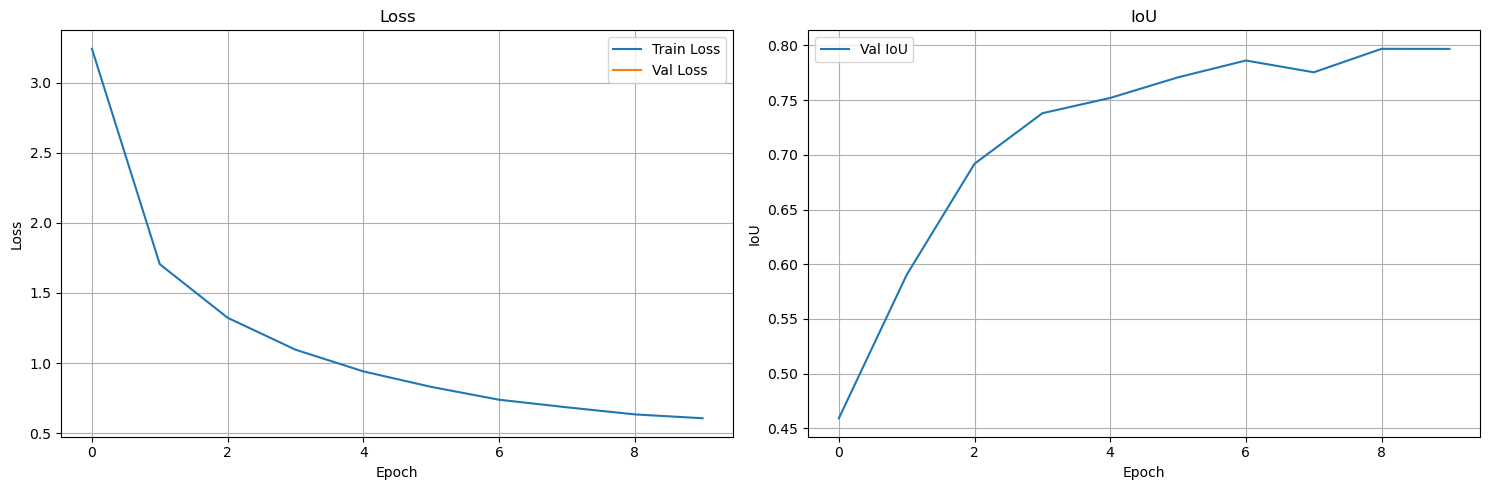


=== Performance Metrics Summary ===
IoU     - Best: 0.7968 | Final: 0.7967
Val Loss - Best: inf | Final: inf



,epoch,train_loss,val_loss,val_iou
0,1,3.241145,inf,0.459296
1,2,1.705087,inf,0.590377
2,3,1.323034,inf,0.691858
3,4,1.095389,inf,0.737991
4,5,0.940644,inf,0.751981
5,6,0.830247,inf,0.770801
6,7,0.738614,inf,0.786158
7,8,0.684541,inf,0.775382
8,9,0.633941,inf,0.796849
9,10,0.606429,inf,0.796750


In [19]:
geoai.plot_performance_metrics(
    history_path=f"{out_folder}/instance_models/training_history.pth",
    figsize=(15, 5),
    verbose=True,
)

## Instance vs Semantic Segmentation Comparison

### When to use Instance Segmentation:

1. **Individual object analysis**: When you need to count, measure, or analyze individual objects
2. **Overlapping objects**: When objects of the same class may overlap or touch
3. **Object tracking**: When tracking individual objects across frames or images
4. **Spatial relationships**: When analyzing relationships between individual objects

### When to use Semantic Segmentation:

1. **Area coverage**: When you only need to know what percentage of an image contains a certain class
2. **Land cover mapping**: For continuous features like vegetation, water, roads
3. **Simpler models**: When you want faster training and inference
4. **Pixel-level classification**: When object boundaries are less important

### Model Outputs:

**Instance Segmentation (Mask R-CNN)**:
- Bounding boxes for each object
- Confidence scores for each detection
- Binary mask for each individual object
- Class label for each object

**Semantic Segmentation**:
- Single multi-class mask covering the entire image
- Probability map (optional)
- No distinction between individual objects

### Performance Considerations:

| Aspect | Instance Segmentation | Semantic Segmentation |
|--------|----------------------|----------------------|
| **Training Time** | Slower (more complex model) | Faster |
| **Inference Time** | Slower | Faster |
| **Memory Usage** | Higher | Lower |
| **Accuracy** | Better for distinct objects | Better for continuous classes |
| **Typical Batch Size** | 2-8 | 8-32 |

### Metrics:

**Instance Segmentation Metrics**:
- **AP (Average Precision)**: Precision at different IoU thresholds
- **AP@0.5**: Average Precision at IoU threshold of 0.5
- **AP@0.75**: Average Precision at IoU threshold of 0.75
- **AR (Average Recall)**: Recall averaged across IoU thresholds

**Semantic Segmentation Metrics**:
- **IoU (Intersection over Union)**: Overlap between prediction and ground truth
- **Dice Score**: Similar to IoU but more sensitive to small objects
- **Pixel Accuracy**: Percentage of correctly classified pixels

## Batch Processing (Optional)

If you have multiple images to process, you can use the batch inference function:

In [20]:
# Uncomment to process multiple images
# geoai.instance_segmentation_batch(
#     input_dir="path/to/input/images",
#     output_dir="path/to/output/masks",
#     model_path=model_path,
#     num_classes=2,
#     num_channels=3,
#     window_size=512,
#     overlap=256,
#     confidence_threshold=0.5,
#     batch_size=4,
# )

## Advanced: Multi-channel Input (RGBN)

If your imagery includes a near-infrared (NIR) band, you can train with 4 channels:

In [21]:
# Example for 4-channel (RGBN) imagery
# geoai.train_instance_segmentation_model(
#     images_dir=f"{out_folder}/images",
#     labels_dir=f"{out_folder}/labels",
#     output_dir=f"{out_folder}/instance_models_rgbn",
#     num_classes=2,
#     num_channels=4,  # RGB + NIR
#     batch_size=4,
#     num_epochs=10,
#     learning_rate=0.005,
#     val_split=0.2,
#     verbose=True,
# )